In [1]:
from alerce.core import Alerce
from astropy.table import Table
import matplotlib.pyplot as plt
import pyvo as vo
import requests
import sqlalchemy as sa
import sys
import numpy as np
from astropy.coordinates import SkyCoord
from astropy import units as u
import re
import george
import scipy.optimize as op
import emcee
from IPython.display import clear_output

In [2]:
alerce = Alerce()
alerce_tap = vo.dal.TAPService('https://tap.alerce.online/tap')

In [3]:
filename = "../Data/tns_Ia.csv"
sources = Table.read(filename, format="csv")
sources[0]

objid,name_prefix,name,ra,declination,redshift,typeid,type,reporting_groupid,reporting_group,source_groupid,source_group,discoverydate,discoverymag,discmagfilter,filter,reporters,time_received,internal_names,Discovery_ADS_bibcode,Class_ADS_bibcodes,creationdate,lastmodified
int64,str2,str8,float64,float64,float64,int64,str5,int64,str17,int64,str5,str23,float64,int64,str1,str454,str19,str146,str19,str61,str19,str19
207908,SN,2026lns,202.4570465,-5.7516547,0.0686,3,SN Ia,48,ZTF,48,ZTF,2026-05-07 05:03:27.996,19.2662,111,r,"Jesper Sollerman (SU), Christoffer Fremling (Caltech), Daniel Perley (LJMU), Theophile du Laz (Caltech) on behalf of ZTF",2026-05-07 09:15:10,"ZTF26aauvdne, GOTO26ejc, , ATLAS26fhx",2026TNSTR1975....1S,--,2026-05-07 09:15:12,2026-05-11 05:50:45


In [4]:
ZTF_mask = sources["source_group"] == "ZTF"
ZTF = sources[ZTF_mask]
ZTF[0]

objid,name_prefix,name,ra,declination,redshift,typeid,type,reporting_groupid,reporting_group,source_groupid,source_group,discoverydate,discoverymag,discmagfilter,filter,reporters,time_received,internal_names,Discovery_ADS_bibcode,Class_ADS_bibcodes,creationdate,lastmodified
int64,str2,str8,float64,float64,float64,int64,str5,int64,str17,int64,str5,str23,float64,int64,str1,str454,str19,str146,str19,str61,str19,str19
207908,SN,2026lns,202.4570465,-5.7516547,0.0686,3,SN Ia,48,ZTF,48,ZTF,2026-05-07 05:03:27.996,19.2662,111,r,"Jesper Sollerman (SU), Christoffer Fremling (Caltech), Daniel Perley (LJMU), Theophile du Laz (Caltech) on behalf of ZTF",2026-05-07 09:15:10,"ZTF26aauvdne, GOTO26ejc, , ATLAS26fhx",2026TNSTR1975....1S,--,2026-05-07 09:15:12,2026-05-11 05:50:45


In [5]:
#ZTF["internal_names"][0][:12]
ZTF_obj_Ia = []
pattern = r"ZTF"
for obj in ZTF["internal_names"]:
    #print(obj)
    if isinstance(obj, str):
        internal = obj.split(',')
        survay_name = [name for name in internal if re.search(pattern, name)]
        if survay_name:
            ZTF_obj_Ia.append(survay_name[0])

ZTF_obj_Ia = np.array(ZTF_obj_Ia)
print(len(ZTF_obj_Ia))

6425


In [6]:
light = alerce.query_forced_photometry(ZTF_obj_Ia[788], format="json")

In [7]:
light[0]
#plt.scatter(light["detections"])

{'candid': 'ZTF25aapxtna3051301400015',
 'tid': 'ztf',
 'pid': 3051301400015,
 'oid': 'ZTF25aapxtna',
 'mjd': 60805.301400499884,
 'fid': 1,
 'ra': 266.5103716,
 'e_ra': None,
 'dec': 59.3242615,
 'e_dec': None,
 'mag': 23.005868911743164,
 'e_mag': 2.789698839187622,
 'mag_corr': None,
 'e_mag_corr': None,
 'e_mag_corr_ext': None,
 'isdiffpos': 1,
 'corrected': False,
 'dubious': False,
 'parent_candid': 3051405890015015023,
 'has_stamp': False,
 'rcid': 0,
 'magzpscirms': 0.03588009998202324,
 'distnr': 1.8383314609527588,
 'rfid': 825120100,
 'clrcoeff': -0.07130610197782516,
 'ranr': 266.5104064941406,
 'sciinpseeing': 2.373699903488159,
 'clrcounc': 1.892769978439901e-05,
 'decnr': 59.32374954223633,
 'scibckgnd': 87.51290130615234,
 'exptime': 30.0,
 'magnr': 18.871999740600586,
 'scisigpix': 12.036999702453613,
 'adpctdif1': 0.06800500303506851,
 'sigmagnr': 0.07100000232458115,
 'magzpsci': 26.241199493408203,
 'adpctdif2': 0.096950002014637,
 'chinr': 3.5160000324249268,
 'dif

<ErrorbarContainer object of 3 artists>

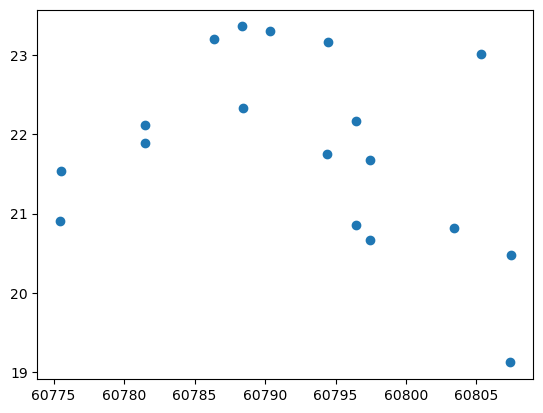

In [8]:
time = [obs["mjd"] for obs in light]
mag = [obs["mag"] for obs in light]
error = [obs["e_mag"] for obs in light]

plt.errorbar(time, mag, fmt='o')#, yerr=error)

In [9]:
#fitting curve
kernel =  np.var(mag) * george.kernels.ExpSquaredKernel(80)

In [10]:
gp = george.GP(kernel)

In [11]:
gp.compute(time, error)

In [12]:
x_fit = np.linspace(np.min(time) - 5, np.max(time) + 100, 500)#num=len(y))
pred, pred_var = gp.predict(mag, x_fit, return_var=True)
print(pred)

[1.49687823e+01 1.52905216e+01 1.56074230e+01 1.59190305e+01
 1.62249031e+01 1.65246163e+01 1.68177644e+01 1.71039619e+01
 1.73828446e+01 1.76540719e+01 1.79173276e+01 1.81723209e+01
 1.84187882e+01 1.86564932e+01 1.88852282e+01 1.91048145e+01
 1.93151030e+01 1.95159743e+01 1.97073390e+01 1.98891376e+01
 2.00613405e+01 2.02239472e+01 2.03769865e+01 2.05205150e+01
 2.06546172e+01 2.07794039e+01 2.08950114e+01 2.10016004e+01
 2.10993547e+01 2.11884796e+01 2.12692007e+01 2.13417622e+01
 2.14064253e+01 2.14634666e+01 2.15131765e+01 2.15558572e+01
 2.15918212e+01 2.16213894e+01 2.16448896e+01 2.16626545e+01
 2.16750205e+01 2.16823256e+01 2.16849080e+01 2.16831048e+01
 2.16772504e+01 2.16676753e+01 2.16547047e+01 2.16386576e+01
 2.16198455e+01 2.15985718e+01 2.15751304e+01 2.15498057e+01
 2.15228715e+01 2.14945906e+01 2.14652145e+01 2.14349829e+01
 2.14041238e+01 2.13728530e+01 2.13413744e+01 2.13098797e+01
 2.12785490e+01 2.12475506e+01 2.12170411e+01 2.11871662e+01
 2.11580606e+01 2.112984

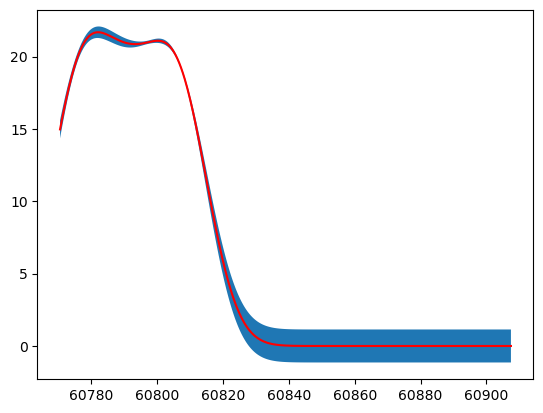

In [13]:
plt.plot(x_fit, pred, color='r')
error2 = np.pow(pred_var, 0.5)

plt.fill_between(x_fit, pred - error2, pred + error2, interpolate=True)

In [14]:
# light_corrected = (corr for corr in light if corr["corrected"])

In [15]:
# time = [obs["mjd"] for obs in light_corrected]
# mag = [obs["mag"] for obs in light_corrected]
# error = [obs["e_mag"] for obs in light_corrected]

# plt.errorbar(time, mag, fmt='o')

In [16]:
# Define the objective function (negative log-likelihood in this case).
def nll(p, mag):
    gp.set_parameter_vector(p)
    ll = gp.log_likelihood(mag, quiet=True)
    return -ll if np.isfinite(ll) else 1e25

# And the gradient of the objective function.
def grad_nll(p, mag):
    gp.set_parameter_vector(p)
    return -gp.grad_log_likelihood(mag, quiet=True)

In [17]:
# Print the initial ln-likelihood.
print(gp.log_likelihood(mag))

# Run the optimization routine.
p0 = gp.get_parameter_vector()
results = op.minimize(nll, p0, jac=grad_nll, method="L-BFGS-B")

# Update the kernel and print the final log-likelihood.
gp.set_parameter_vector(results.x)
print(gp.log_likelihood(mag))

-407.86748316672333
-44.10395915179324


In [18]:
pred, pred_var = gp.predict(mag, x_fit, return_var=True)

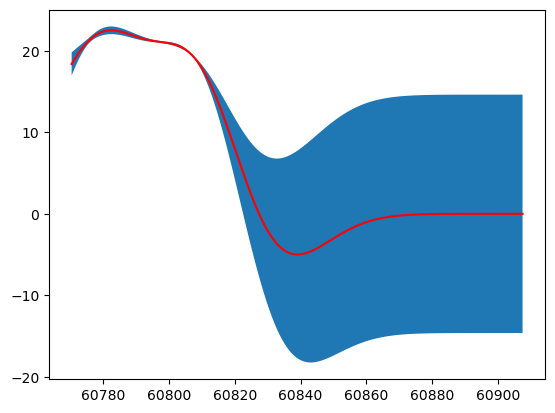

In [19]:
plt.plot(x_fit, pred, color='r')
error3 = np.pow(pred_var, 0.5)

plt.fill_between(x_fit, pred - error3, pred + error3, interpolate=True)

In [20]:
def lnprob(p):
    # Trivial uniform prior.
    if np.any((-100 > p[1:]) + (p[1:] > 100)):
        return -np.inf

    # Update the kernel and compute the lnlikelihood.
    gp.set_parameter_vector(p)
    return gp.lnlikelihood(mag, quiet=True)

In [21]:
# Set up the sampler.
nwalkers, ndim = 100, len(gp)
sampler = emcee.EnsembleSampler(nwalkers, ndim, lnprob)

# Initialize the walkers.
p0 = gp.get_parameter_vector() + 1e-4 * np.random.randn(nwalkers, ndim)

print("Running burn-in")
p0, _, _ = sampler.run_mcmc(p0, 200)

print("Running production chain")
sampler.run_mcmc(p0, 200);

Running burn-in
Running production chain


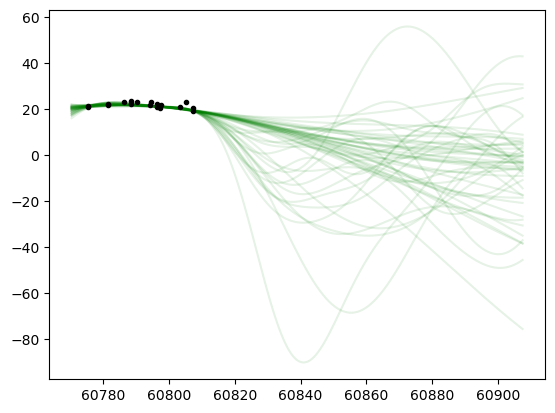

In [22]:
for i in range(50):
    # Choose a random walker and step.
    w = np.random.randint(sampler.chain.shape[0])
    n = np.random.randint(sampler.chain.shape[1])
    gp.set_parameter_vector(sampler.chain[w, n])

    # Plot a single sample.
    plt.plot(x_fit, gp.sample_conditional(mag, x_fit), "g", alpha=0.1)

plt.plot(time, mag, ".k")

In [49]:
def log_prior(theta, mini=100, maxi=1000):
    """
    Returns log(prior) for a given parameter vector
    
    Parameters
    ----------
    theta: list, array-like
        List of parameters in the form [slope, intercept]
    
    Returns
    -------
    ln_prior: float
        Natural log of the prior probability function
    """
    kernal = theta#, size, before, after = theta
    
    kern_cond = (kernal > mini)# & (kernal < maxi)
    #size_cond = (size > mini) & (size < maxi)
    #before_cond = (before > 0) & (before < 100)
    #after_cond = (after > 0) & (after < 300)

    return np.log(kern_cond)# & before_cond & after_cond)

def log_likelihood(theta, time, mag, dmag):
    """complete"""
    #unpack hyperparameters
    kernal = theta#, size, before, after = theta
    
    kern =  np.var(mag) * george.kernels.ExpSquaredKernel(np.abs(kernal))
    gp = george.GP(kern)
    gp.compute(time, dmag)
    
    #x_fit = np.linspace(np.min(time) - before, np.max(time) + after, int(size))
    pred, pred_var = gp.predict(mag, time, return_var=True)

    likelihood = -0.5 * np.sum(((mag - pred) / (dmag + pred_var))**2, axis=-1)
    #print(likelihood)
    return likelihood

def log_posterior(theta, time, mag, dmag):
    """complete"""

    #print(theta)
    return log_likelihood(theta, time, mag, dmag) + log_prior(theta)

In [47]:
rng = np.random.default_rng()

n_params = 1
n_walkers = 100
n_steps = 10000

kern_random = (rng.random(n_walkers) * 1000)
#print(kern_random)
size_random = (rng.random(n_walkers) * 100)
before_random = (rng.random(n_walkers) * 100)
after_random = (rng.random(n_walkers) * 100)

initial_guesses = np.array([kern_random])#, size_random, before_random, after_random])

In [50]:
# initialize the sampler
sampler = emcee.EnsembleSampler(n_walkers, n_params, log_posterior, args=[time, mag, error])  # complete

# run!
sampler.run_mcmc(initial_guesses.T, n_steps)  # complete

clear_output() 

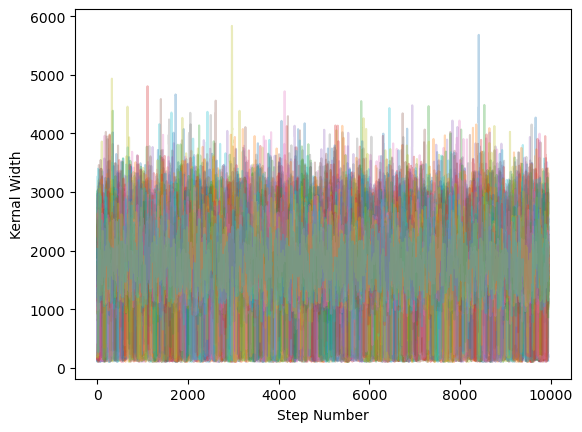

In [52]:
def chain_plots(chain, burn=50):
    """
    Plot the histories for each walker in sampler.chain
    
    Parameters
    ----------
    chain: ndarray
        3D array given by sampler.flatchain, with shape (n_walkers, n_steps, n_params)
    kwargs: `.Line2D` properties, optional
        All keyword arguments are passed to `pyplot.plot`
    """
    chain = np.swapaxes(chain, 0, 1)
    
    plt.figure()
    plt.plot(chain[burn:, :, 0], alpha=0.3)
    plt.xlabel('Step Number')
    plt.ylabel('Kernal Width')

    # plt.figure()
    # plt.plot(chain[burn:, :, 1], alpha=0.3)
    # plt.xlabel('Step Number')
    # plt.ylabel('Days Before')

    # plt.figure()
    # plt.plot(chain[burn:, :, 2], alpha=0.3)
    # plt.xlabel('Step Number')
    # plt.ylabel('Days After')
    
chain_plots(sampler.chain)

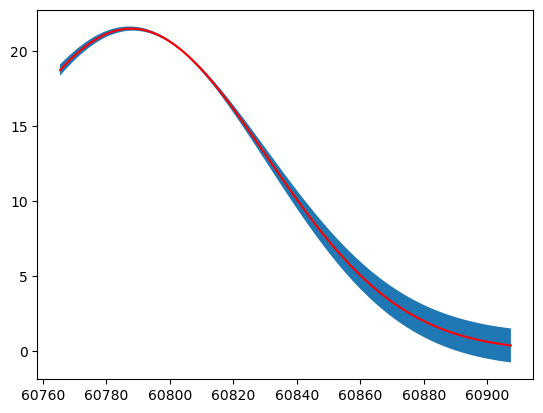

In [54]:
flat = sampler.get_chain(discard=50, flat=True)

kernel =  np.var(mag) * george.kernels.ExpSquaredKernel(np.median(flat))
gp = george.GP(kernel)
gp.compute(time, error)
x_fit = np.linspace(np.min(time) - 10, np.max(time) + 100, 500)
pred, pred_var = gp.predict(mag, x_fit, return_var=True)

plt.plot(x_fit, pred, color='r')
error2 = np.pow(pred_var, 0.5)

plt.fill_between(x_fit, pred - error2, pred + error2, interpolate=True)